In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

import urllib.request

**The HR diagram** (and the importance of data scaling in machine learning)

This assignment is about stars: we will work with a star catalogue of 240 stars described by the following information (these are **features**):

1. Temperature (in Kelvin)
2. Luminosity (L/Lo)
3. Radius (R/Ro)
4. Absolute magnitude (Mv)

We also have the following data for each star (these are **possible labels**):

1. Color (Red/Orange/Yellow/White/Blue)
2. Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
3. Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

In [2]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x7f5961172390>)

In [3]:
table_stars = pd.read_csv("stars.csv")
print(table_stars.shape)

(240, 7)


In [4]:
table_stars.sample(frac=0.05, random_state=42)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
24,16500,0.01300,0.01400,11.89,White Dwarf,Blue White,B
6,2637,0.00073,0.12700,17.22,Brown Dwarf,Red,M
93,4980,0.35700,1.13000,4.78,Main Sequence,Yellowish,K
109,33421,352000.00000,67.00000,-5.79,Supergiant,Blue,O
104,11096,112000.00000,12.00000,-5.91,Supergiant,Blue,O
172,4287,630000.00000,1315.00000,-9.20,Hypergiant,Orange,K
233,27739,849420.00000,1252.00000,-7.59,Hypergiant,Blue-white,B
86,12010,0.00078,0.00920,12.13,White Dwarf,Blue White,B
9,2700,0.00018,0.13000,16.05,Brown Dwarf,Red,M
143,14520,0.00082,0.00972,11.92,White Dwarf,Blue White,B


**To do list:**

1. Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
2. Project the dataset into the principal components, and do a scatter plot of the first two.

This will look terrible. Think about the units!
Explore what happens if you rescale the data first.
This is actually a very important lesson in machine learning: massaging your data before giving them to an algorithm can make things much much better.

You can try a linear, affine transformation such that each dimension goes between -1 and 1 or (which is the usual machine-learning approach) standardize your data such that each dimension has mean=0 and variance=1.
Redo your PCA. Should be much much better.

3. How much variance is explained by those two components?

In [5]:
# Assign unique integers from 0 to 6 to each star type
le = LabelEncoder()
table_stars['Star type'] = le.fit_transform(table_stars['Star type'])
labels = le.inverse_transform(table_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [6]:
table_stars.sample(frac=0.05, random_state=42)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
24,16500,0.01300,0.01400,11.89,5,Blue White,B
6,2637,0.00073,0.12700,17.22,0,Red,M
93,4980,0.35700,1.13000,4.78,2,Yellowish,K
109,33421,352000.00000,67.00000,-5.79,4,Blue,O
104,11096,112000.00000,12.00000,-5.91,4,Blue,O
172,4287,630000.00000,1315.00000,-9.20,1,Orange,K
233,27739,849420.00000,1252.00000,-7.59,1,Blue-white,B
86,12010,0.00078,0.00920,12.13,5,Blue White,B
9,2700,0.00018,0.13000,16.05,0,Red,M
143,14520,0.00082,0.00972,11.92,5,Blue White,B


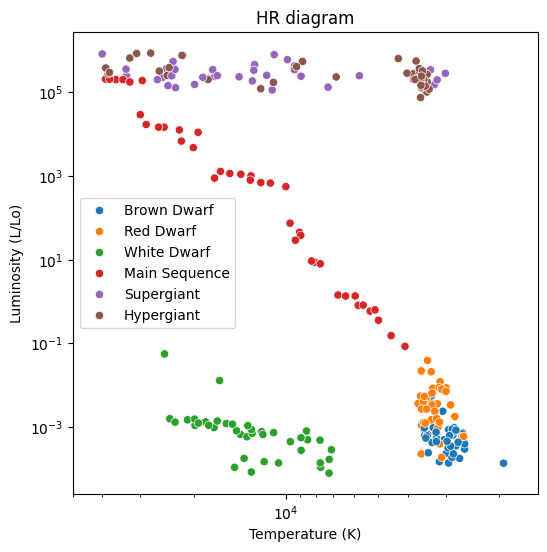

In [7]:
fig = plt.figure(figsize=(6, 6))
sns.scatterplot(data=table_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)
plt.title("HR diagram")
plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity (L/Lo)")
plt.xscale('log')
plt.yscale('log')
plt.xlim(5e4, 1.5e3)
plt.show()

In [8]:
# remember sklearn requires format (n_samples, n_features)
x1 = table_stars["Temperature (K)"]
x2 = table_stars["Luminosity(L/Lo)"]
x3 = table_stars["Radius(R/Ro)"]
x4 = table_stars["Absolute magnitude(Mv)"]
y = table_stars["Star type"]
X = np.array([x1, x2, x3, x4]).T

In [9]:
X.shape

(240, 4)

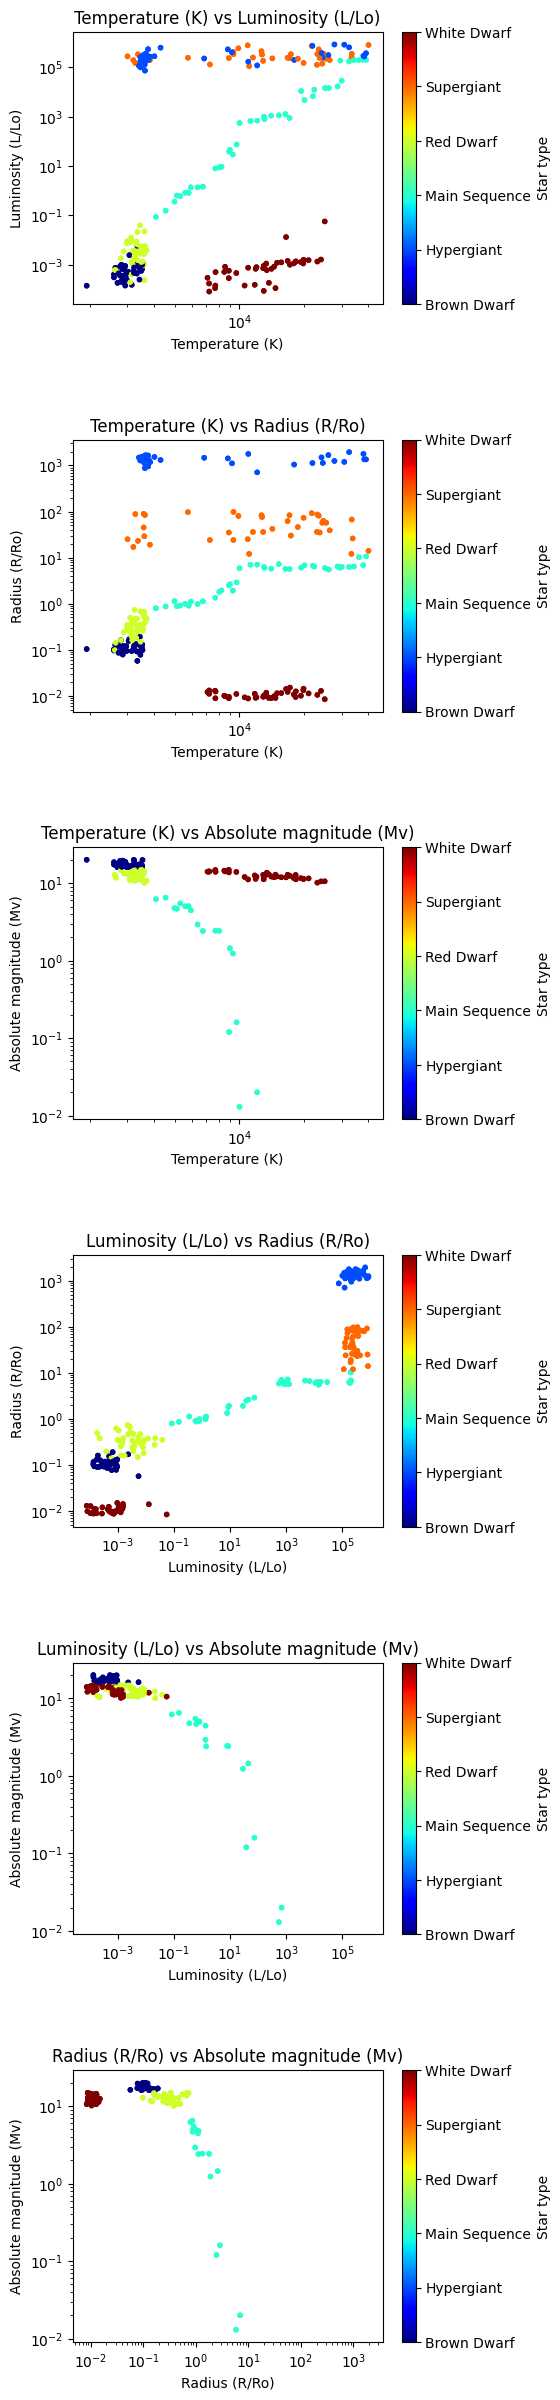

In [10]:
X_labels = ["Temperature (K)", "Luminosity (L/Lo)", "Radius (R/Ro)", "Absolute magnitude (Mv)"]
fig, axes = plt.subplots(6, 1, figsize=(5, 30))
fig.subplots_adjust(hspace=0.5, wspace=0.5)
count = 0
for i in range(4):
  for j in range(4):
    if j > i:
      axes[count].scatter(X[:, i], X[:, j], c=y, cmap='jet', marker=".")
      axes[count].set_xlabel(X_labels[i])
      axes[count].set_ylabel(X_labels[j])
      axes[count].set_title(X_labels[i]+" vs "+X_labels[j])
      axes[count].set_xscale('log')
      axes[count].set_yscale('log')
      cbar = fig.colorbar(axes[count].scatter(X[:, i], X[:, j], c=y, cmap='jet', marker="."), ax=axes[count])
      cbar.set_label('Star type')
      cbar.set_ticks(np.arange(0, 6, 1))
      cbar.set_ticklabels(class_names)
      count += 1

In [11]:
n = 2 # n_components can be optionally set
pca = PCA(n_components=n)
pca.fit(X)

X_pca = pca.transform(X) # objects' coordinates onto the new basis in the features space
mean = pca.mean_ # mean values in the features space (the average for each dimension)
eigenvalues = pca.explained_variance_ # entries of the dataset's diagonalized covariance matrix
eigenvectors = pca.components_ # the new basis in the features space
evals = pca.explained_variance_ratio_ # how to know which component explains the most variance

# Reconstruction of objects onto the original basis
X_reconstructed = mean + np.dot(X_pca, eigenvectors)

print("transformed dataset:", X_pca.shape)
print("eigenvalues:", eigenvalues.shape)
print("eigenvectors:", eigenvectors.shape)
print("mean:", mean.shape)
print("reconstructed dataset:", X_reconstructed.shape)
print("Explained fractional variance of data encapsulated in the eigenvalues:",evals," Total:",np.sum(evals))

transformed dataset: (240, 2)
eigenvalues: (2,)
eigenvectors: (2, 4)
mean: (4,)
reconstructed dataset: (240, 4)
Explained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]  Total: 0.9999942118846565


In [12]:
for i in range(len(eigenvectors)):
  print("Eigenvector n.",i)
  print(" + ".join("%.5f %s" % (value, name) for value, name in zip(eigenvectors[i], X_labels)))
  print("\n")

Eigenvector n. 0
0.02099 Temperature (K) + 0.99978 Luminosity (L/Lo) + 0.00152 Radius (R/Ro) + -0.00004 Absolute magnitude (Mv)


Eigenvector n. 1
0.99974 Temperature (K) + -0.02097 Luminosity (L/Lo) + -0.00921 Radius (R/Ro) + -0.00019 Absolute magnitude (Mv)




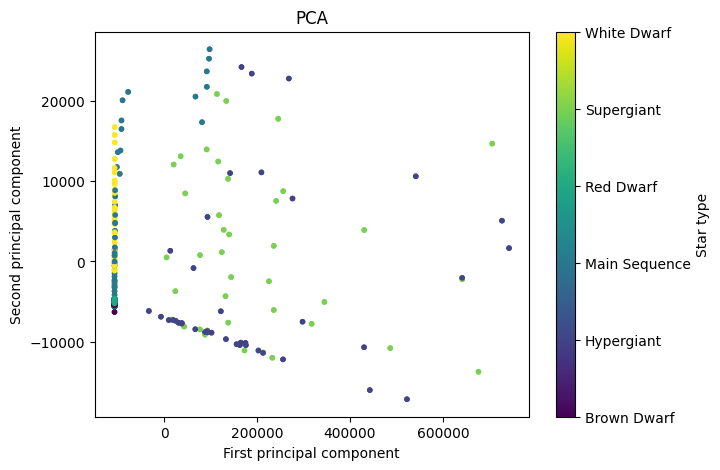

In [13]:
fig, axes = plt.subplots(figsize=(7, 5))
axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', marker=".")
axes.set_xlabel("First principal component")
axes.set_ylabel("Second principal component")
axes.set_title("PCA")
cbar = fig.colorbar(axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', marker="."), ax=axes)
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

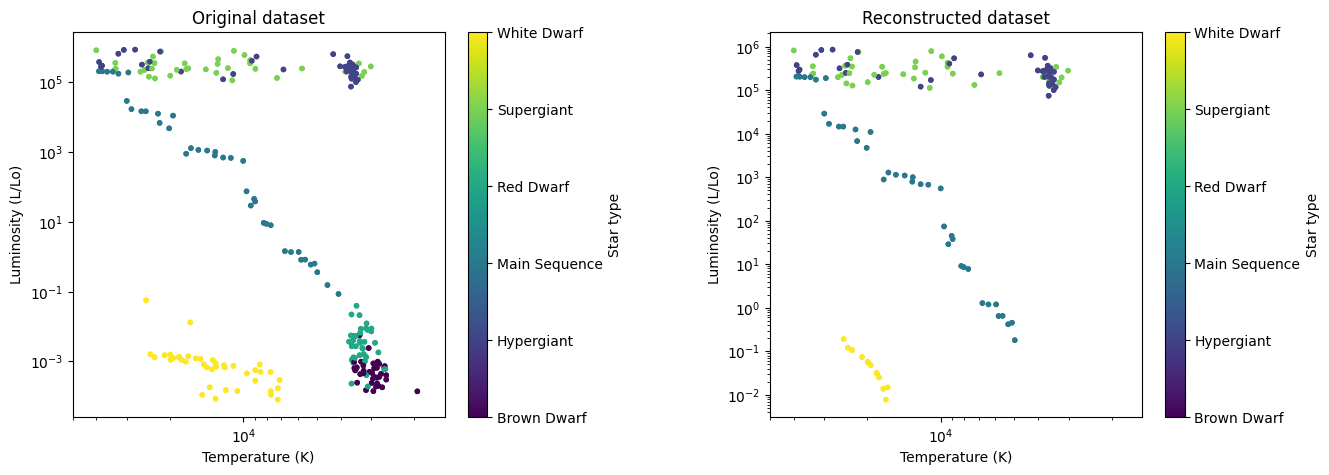

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker=".")
axes[0].set_xlabel(X_labels[0])
axes[0].set_ylabel(X_labels[1])
axes[0].set_title(f"Original dataset")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(5e4, 1.5e3)
cbar = fig.colorbar(axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker="."), ax=axes[0])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='viridis', marker=".")
axes[1].set_xlabel(X_labels[0])
axes[1].set_ylabel(X_labels[1])
axes[1].set_title(f"Reconstructed dataset")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim(5e4, 1.5e3)
cbar = fig.colorbar(axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='viridis', marker="."), ax=axes[1])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

In [15]:
# Standardize your data such that each dimension has mean=0 and variance=1.
# Then redo your PCA. Should be much much better.
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

In [16]:
pca = PCA(n_components=0.95) # if n_components < 1 then n is estimated through an explained variance ratio imposition
pca.fit(X_std)

n = pca.n_components_
X_pca = pca.transform(X_std)
mean = pca.mean_
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
evals = pca.explained_variance_ratio_

X_reconstructed = std_scaler.inverse_transform(mean + np.dot(X_pca, eigenvectors))

print("transformed dataset:", X_pca.shape)
print("eigenvalues:", eigenvalues.shape)
print("eigenvectors:", eigenvectors.shape)
print("mean:", mean.shape)
print("reconstructed dataset:", X_reconstructed.shape)
print("Explained fractional variance of data encapsulated in the eigenvalues:",evals," Total:",np.sum(evals))

transformed dataset: (240, 4)
eigenvalues: (4,)
eigenvectors: (4, 4)
mean: (4,)
reconstructed dataset: (240, 4)
Explained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]  Total: 1.0


In [17]:
for i in range(len(eigenvectors)):
  print("Eigenvector n.",i)
  print(" + ".join("%.5f %s" % (value, name) for value, name in zip(eigenvectors[i], X_labels)))
  print("\n")

Eigenvector n. 0
-0.35018 Temperature (K) + -0.55934 Luminosity (L/Lo) + -0.47477 Radius (R/Ro) + 0.58233 Absolute magnitude (Mv)


Eigenvector n. 1
0.82161 Temperature (K) + 0.00453 Luminosity (L/Lo) + -0.56898 Radius (R/Ro) + 0.03454 Absolute magnitude (Mv)


Eigenvector n. 2
-0.37608 Temperature (K) + 0.75510 Luminosity (L/Lo) + -0.53314 Radius (R/Ro) + 0.06446 Absolute magnitude (Mv)


Eigenvector n. 3
0.24676 Temperature (K) + 0.34198 Luminosity (L/Lo) + 0.40818 Radius (R/Ro) + 0.80966 Absolute magnitude (Mv)




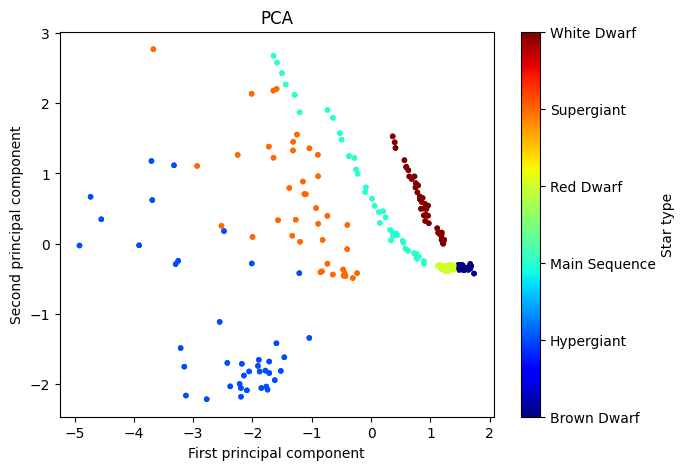

In [18]:
fig, axes = plt.subplots(figsize=(7, 5))
axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='jet', marker=".")
axes.set_xlabel("First principal component")
axes.set_ylabel("Second principal component")
axes.set_title("PCA")
cbar = fig.colorbar(axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='jet', marker="."), ax=axes)
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

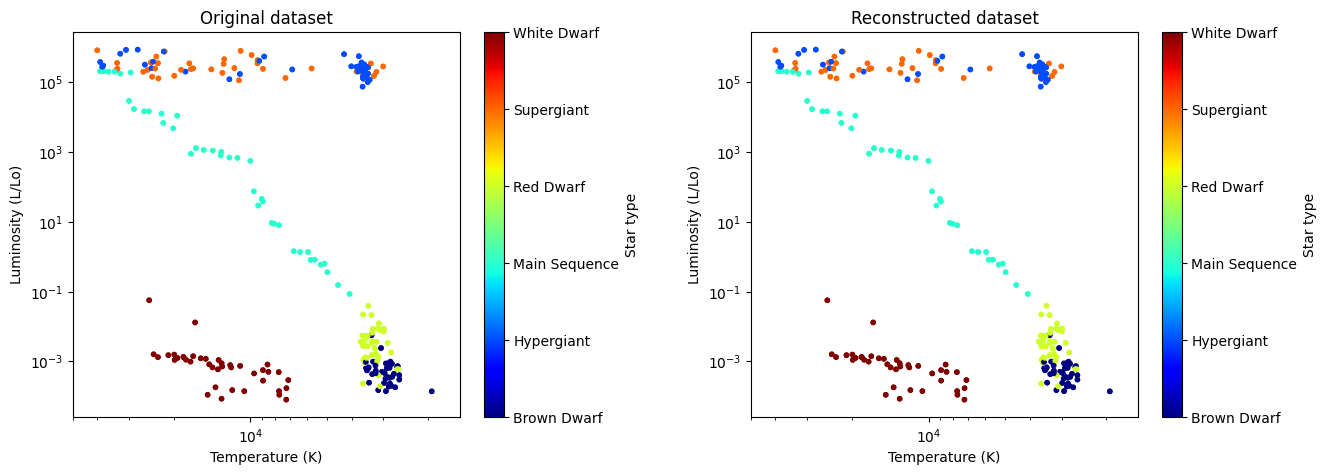

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='jet', marker=".")
axes[0].set_xlabel(X_labels[0])
axes[0].set_ylabel(X_labels[1])
axes[0].set_title(f"Original dataset")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(5e4, 1.5e3)
cbar = fig.colorbar(axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='jet', marker="."), ax=axes[0])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='jet', marker=".")
axes[1].set_xlabel(X_labels[0])
axes[1].set_ylabel(X_labels[1])
axes[1].set_title(f"Reconstructed dataset")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim(5e4, 1.5e3)
cbar = fig.colorbar(axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='jet', marker="."), ax=axes[1])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

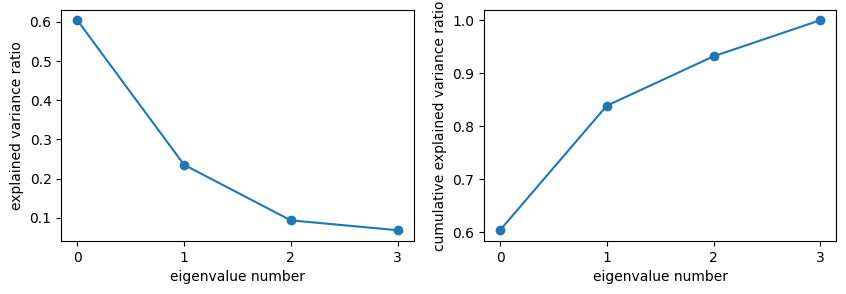

In [20]:
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)
ax.plot(np.arange(n), evals)
ax.scatter(np.arange(n), evals)
ax.set_xticks(np.arange(n))
ax.set_xlabel("eigenvalue number")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)
ax.plot(np.arange(n), evals.cumsum())
ax.scatter(np.arange(n), evals.cumsum())
ax.set_xticks(np.arange(n))
ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

In [21]:
print("The first component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[0]))
print("The second component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[1]))
print("All components (n = {:.0f}) explain {:.3f} of the variance in the data.".format(n, sum(pca.explained_variance_ratio_)))

The first component explains 0.604 of the variance in the data.
The second component explains 0.235 of the variance in the data.
All components (n = 4) explain 1.000 of the variance in the data.
